# Cointegration & Stationarity

In this notebook we wish to explore the ideas of stationarity and then cointegration.

## Setup

First let us import the [`data_loader.py`](data_loader.py) functions and demonstrate how returns are approximately stationary compared to prices.

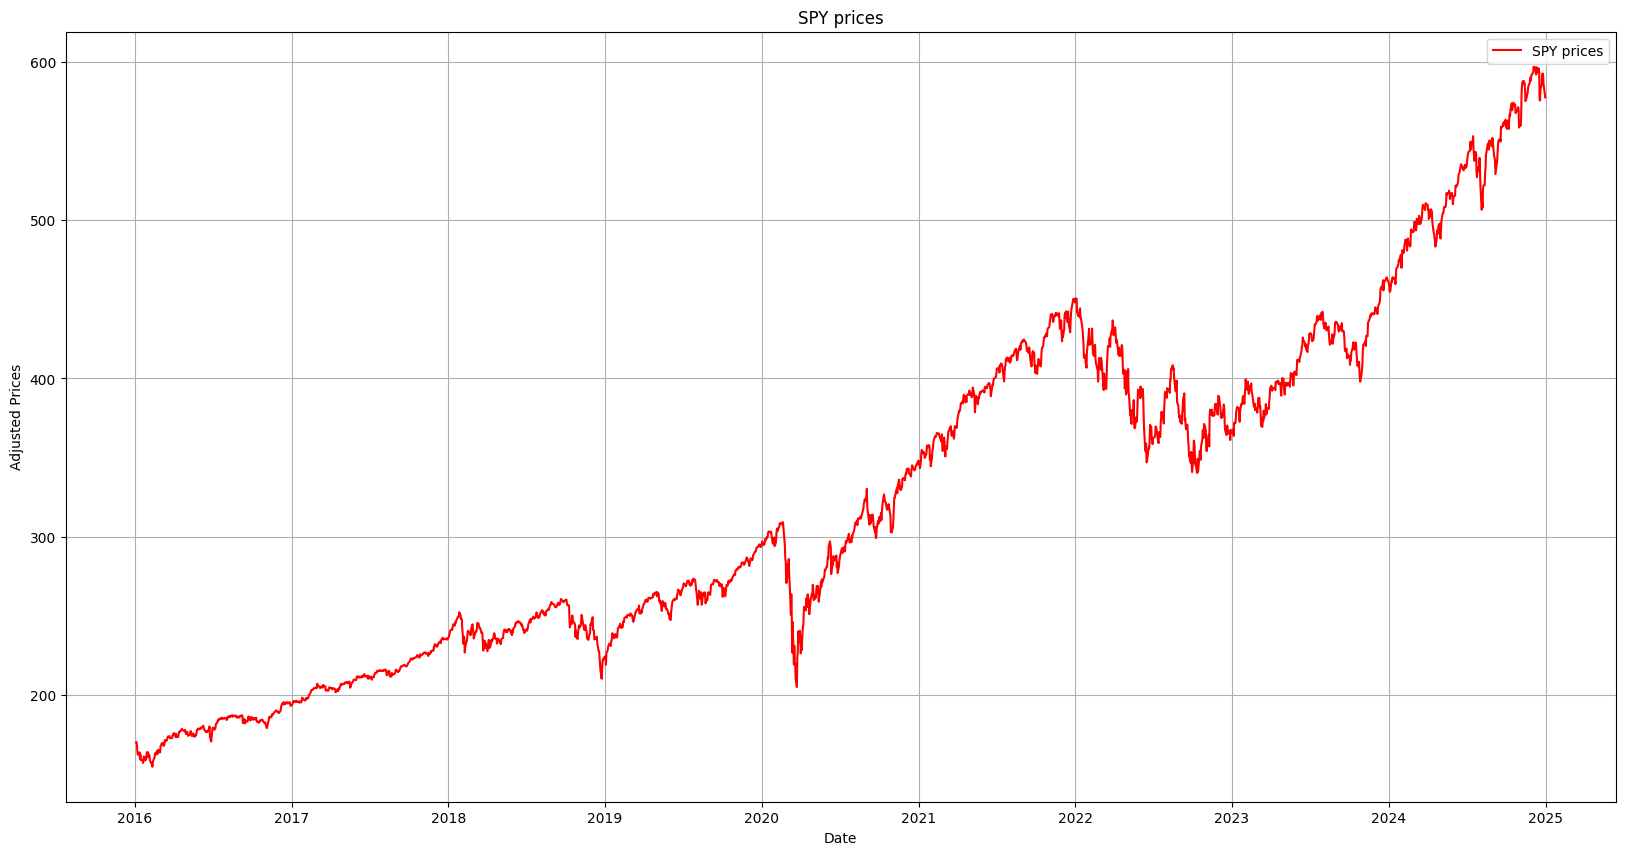

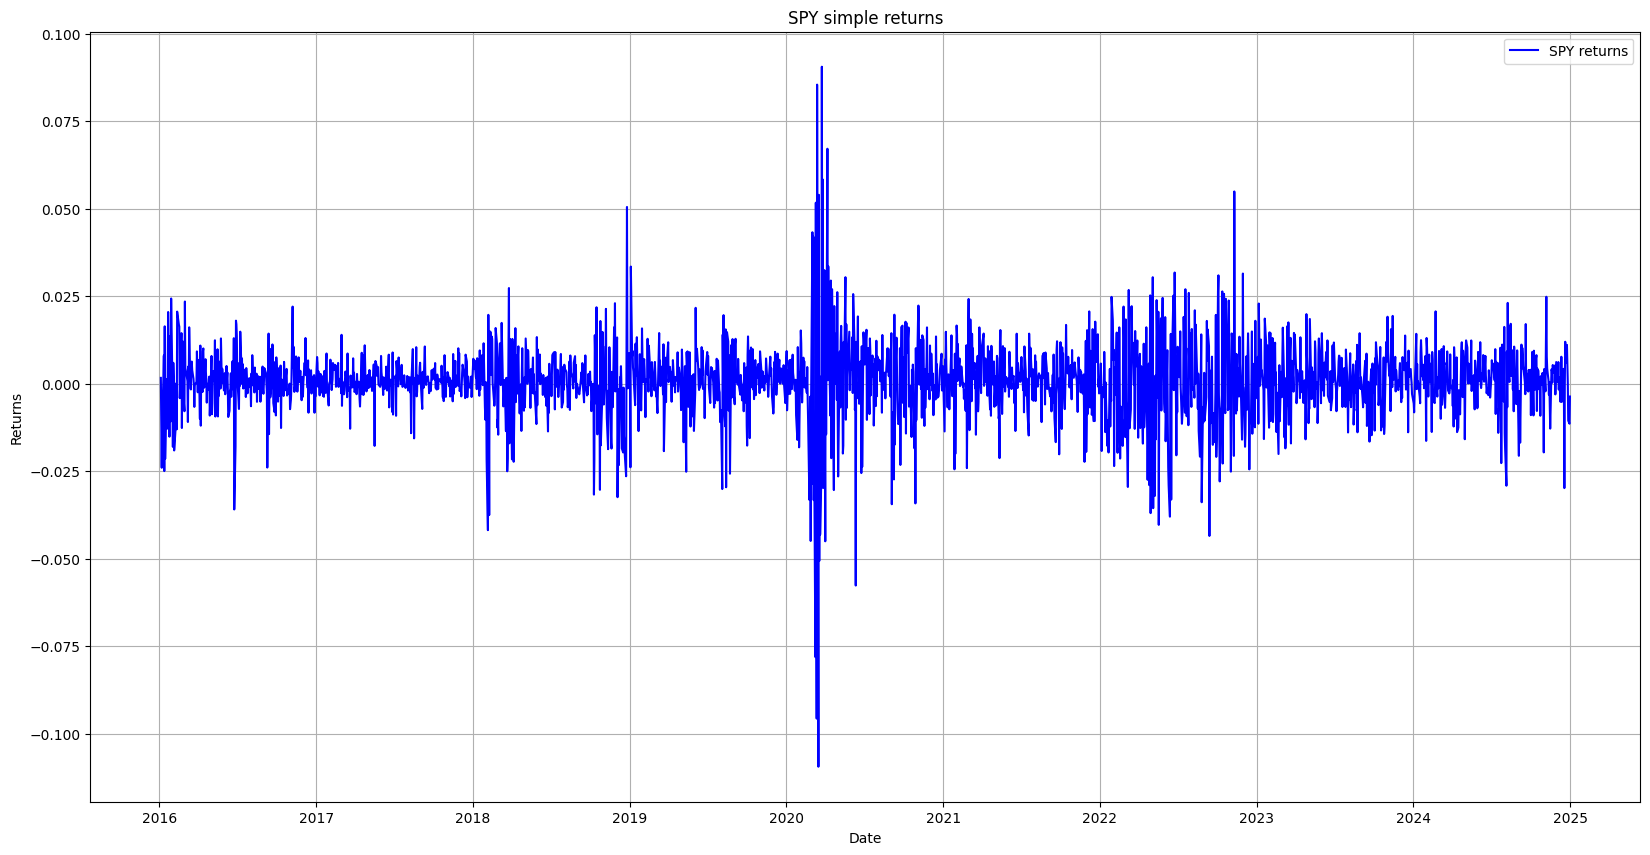

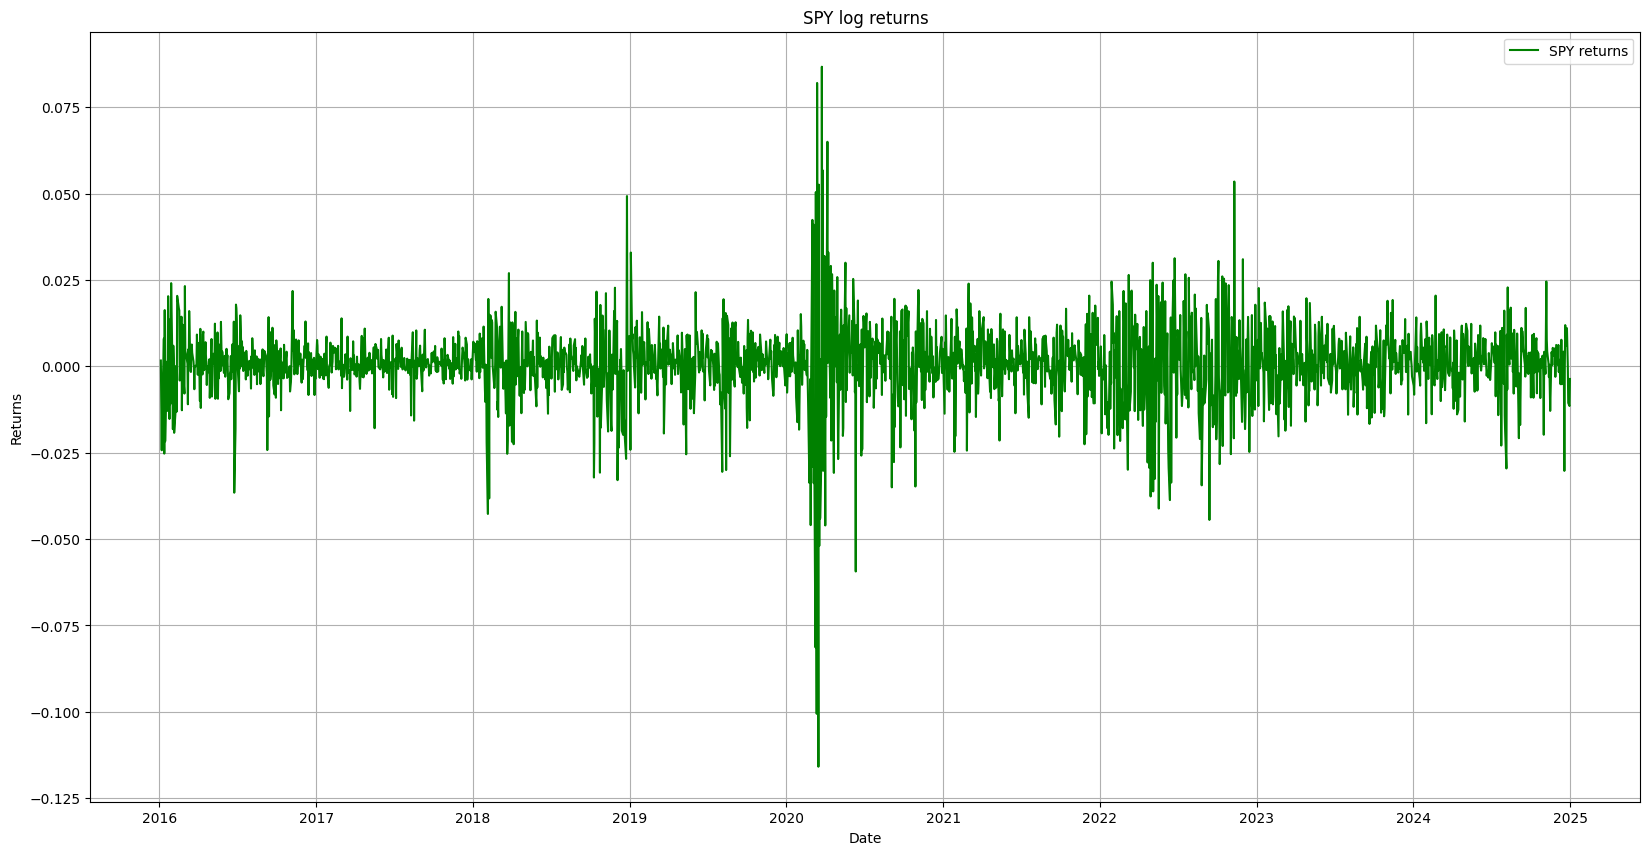

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))

from data_loader import download_prices, compute_returns, get_universe
from cointegration import *
from statsmodels.tsa.stattools import coint



prices_spy = download_prices(['SPY'],'2016-01-01','2025-01-01')

returns_spy = compute_returns(prices_spy,method='simple')
returns_log_spy = compute_returns(prices_spy,method='log')


plt.figure(figsize=(20,10))
plt.plot(prices_spy, label='SPY prices', color='red',)
plt.title('SPY prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Prices')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(returns_spy, label='SPY returns', color='blue')
plt.title('SPY simple returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(returns_log_spy, label='SPY returns', color='green')
plt.title('SPY log returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()

The significant observation from the above plots is that both log and simple returns appear stationary whereas prices are non-stationary. This represents the idea that prices are integrated of order one (I(1)) since differencing prices gives returns.

## Sanity Checks

In order to check that the code in [`cointegration.py`](cointegration.py) works as intended, we test it here on US bank prices and returns. We expect prices should be non-stationary and generally, returns should be stationary.

In [2]:
# Load banks
prices_banks_etfs = download_prices(get_universe('banks')+get_universe('etf_pairs'),'2015-01-01', '2024-12-31')

returns_banks_etfs = compute_returns(prices_banks_etfs, method='log')

for ticker in prices_banks_etfs.columns:
    result = adf_test(prices_banks_etfs[ticker])
    print(f"{ticker} prices: stat={result['statistic']:+6.3f}  p={result['p_value']:.4f}  stationary: {result['is_stationary']}")    
print()

for ticker in returns_banks_etfs.columns:
    result = adf_test(returns_banks_etfs[ticker])
    print(f"{ticker} returns: stat={result['statistic']:+6.3f}  p={result['p_value']:.4f}  stationary: {result['is_stationary']}")

JPM prices: stat=+0.856  p=0.9925  stationary: False
BAC prices: stat=-1.228  p=0.6613  stationary: False
C prices: stat=-2.466  p=0.1240  stationary: False
WFC prices: stat=-1.174  p=0.6849  stationary: False
GS prices: stat=+1.244  p=0.9963  stationary: False
MS prices: stat=+0.331  p=0.9787  stationary: False
SPY prices: stat=+0.759  p=0.9909  stationary: False
IVV prices: stat=+0.771  p=0.9911  stationary: False
QQQ prices: stat=+1.091  p=0.9951  stationary: False
XLK prices: stat=+1.242  p=0.9963  stationary: False

JPM returns: stat=-13.224  p=0.0000  stationary: True
BAC returns: stat=-15.965  p=0.0000  stationary: True
C returns: stat=-9.494  p=0.0000  stationary: True
WFC returns: stat=-16.196  p=0.0000  stationary: True
GS returns: stat=-17.152  p=0.0000  stationary: True
MS returns: stat=-15.649  p=0.0000  stationary: True
SPY returns: stat=-15.726  p=0.0000  stationary: True
IVV returns: stat=-15.692  p=0.0000  stationary: True
QQQ returns: stat=-16.246  p=0.0000  stationar

From the above results, we see that all prices are non-stationary and we can conclude that the corresponding returns are stationary.

Next we check the naive spread of our highest price-correlated pair from `data.ipynb`, which is MS and GS. We will run the ADF test on this spread to check if the spread is stationary.

In [3]:
spread = prices_banks_etfs['MS'] - prices_banks_etfs['GS']
spread_results = adf_test(spread)
print(f"MS - GS spread results: p={spread_results['p_value']:.8f} stationary: {spread_results['is_stationary']}")

MS - GS spread results: p=0.99665880 stationary: False


We can also check the IVV and SPY spread as in `data.ipynb` where we saw that there was a noticeable downwards trend post 2016. This allows us to speculate that the result should be non-stationary with a high p-value.

In [4]:
spread_etfs = prices_banks_etfs['SPY'] - prices_banks_etfs['IVV']
spread_results_etfs = adf_test(spread_etfs)
print(f"SPY - IVV spread results: p={spread_results_etfs['p_value']:.8f} stationary: {spread_results_etfs['is_stationary']}")

SPY - IVV spread results: p=0.99672723 stationary: False


## Cointegration Test

Below we run the Engle-Granger test implemented in [`cointegration.py`](cointegration.py) on the MS, GS pair that had the highest price correlation to explore whether or not the pair is cointegrated.


In [5]:
prices_banks = download_prices(get_universe('banks'), '2015-01-01', '2025-12-31')

result = engle_granger_test(prices_banks['MS'], prices_banks['GS'])
print(f"Personal Engle-Granger implementation: beta={result['beta']:.4f} ADF stat={result['adf_statistic']:.4f} p={result['adf_p_value']:.4f} Cointegrated={result['is_cointegrated']}.")

# Library implementation with proper EG critical values.
coint_stat, coint_p, coint_crit = coint(prices_banks['MS'], prices_banks['GS'])
print(f"sm.coint: ADF stat={coint_stat:.4f}  p={coint_p:.4f}  crit values (1%, 5%, 10%): {coint_crit}")


Personal Engle-Granger implementation: beta=0.2176 ADF stat=-1.8795 p=0.3418 Cointegrated=False.
sm.coint: ADF stat=-1.8806  p=0.5898  crit values (1%, 5%, 10%): [-3.90040673 -3.33834149 -3.0459848 ]


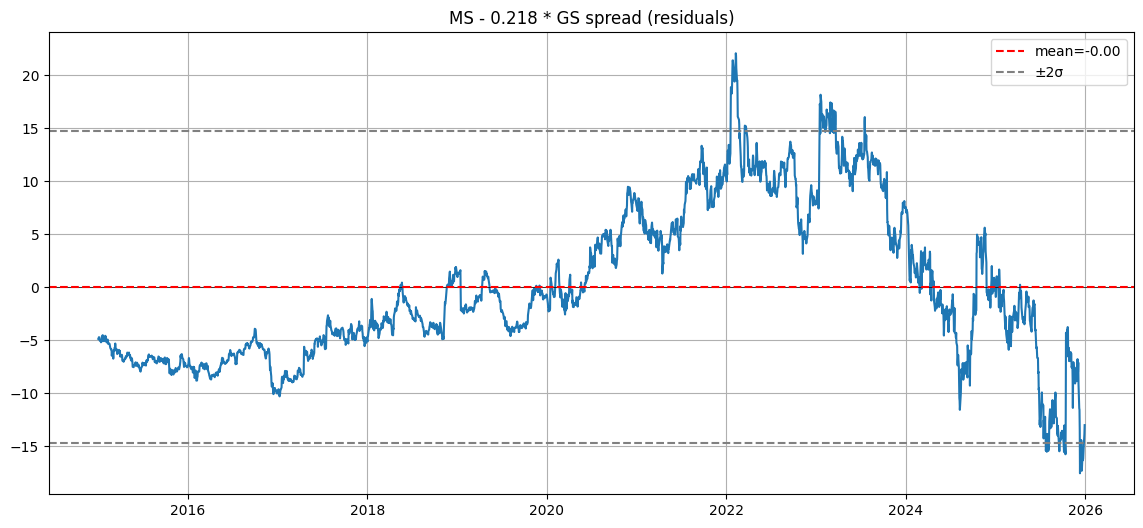

In [6]:
residuals = result['residuals']

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(residuals.mean(), color='red', linestyle='--', label=f'mean={residuals.mean():.2f}')
plt.axhline(residuals.mean() + 2*residuals.std(), color='gray', linestyle='--', label='±2σ')
plt.axhline(residuals.mean() - 2*residuals.std(), color='gray', linestyle='--')
plt.title(f'MS - {result["beta"]:.3f} * GS spread (residuals)')
plt.legend()
plt.grid(True)
plt.show()

From the cointegration values as well as the above plot we can clearly conclude that even with a highly price correlated pair like MS, GS cointegration is not guaranteed.

Next, we will run the cointegration process on many pairs to see if any such pairs are in fact cointegrated.

In [7]:
candidates = [
    ('JPM', 'BAC'),
    ('C', 'BAC'),
    ('SPY', 'IVV'),
    ('KO', 'PEP'), # The canonical example
    ('BHP', 'RIO'), # Both have majority stakes in eachother
    ('EWA', 'EWC') # Historically cointegrated from 2003-2008
]
tickers = ['JPM', 'C', 'BAC', 'SPY', 'IVV', 'KO', 'PEP', 'BHP', 'RIO', 'EWA', 'EWC']

prices_c = download_prices(tickers, '2003-01-01', '2010-12-31')

for y,x in candidates:
    result = engle_granger_test(prices_c[y], prices_c[x])
    stat, p, _ = coint(prices_c[y], prices_c[x])
    half = half_life(result['residuals'])
    print(f"{y}-{x:5s}  beta={result['beta']:+7.4f}  "
      f"my_p={result['adf_p_value']:.4f}  EG_p={p:.4f}  "
      f"R²={result['r_squared']:.3f} half life={half:.2f}")

JPM-BAC    beta=+0.1430  my_p=0.0976  EG_p=0.2500  R²=0.077 half life=74.16
C-BAC    beta=+12.5022  my_p=0.3144  EG_p=0.5611  R²=0.860 half life=127.88
SPY-IVV    beta=+0.9953  my_p=0.0230  EG_p=0.0797  R²=1.000 half life=0.92
KO-PEP    beta=+0.3531  my_p=0.7999  EG_p=0.9250  R²=0.704 half life=244.58
BHP-RIO    beta=+0.9042  my_p=0.7468  EG_p=0.8975  R²=0.753 half life=353.58
EWA-EWC    beta=+0.6020  my_p=0.0180  EG_p=0.0640  R²=0.967 half life=30.15


We see that the lowest p-value pair is EWA, EWC with an Engle-Granger p-value of 0.0640. In order to have an idea of what this implies for the cointegration, we visually plot the spread with the hedge ratio below.

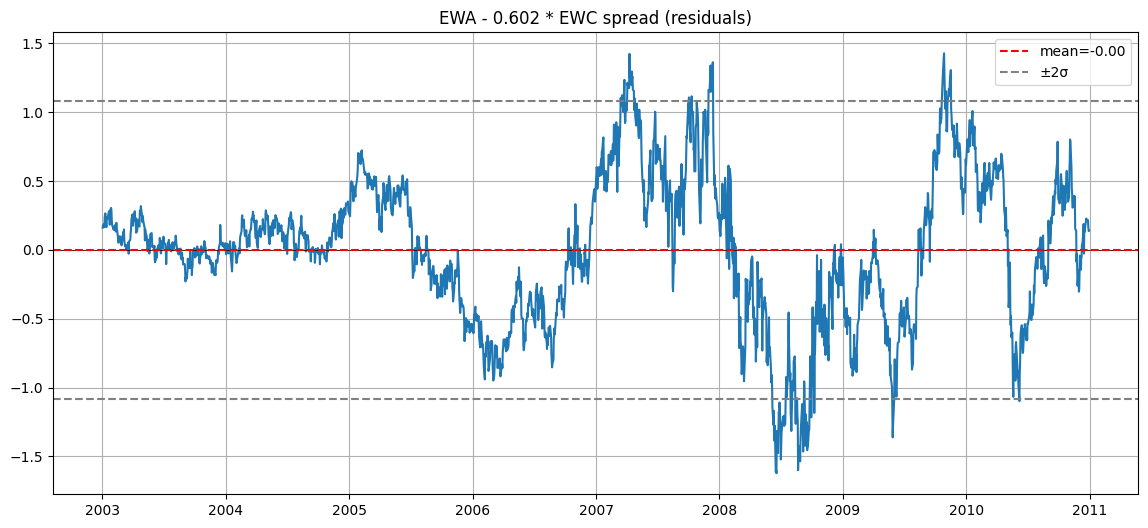

In [8]:
result = engle_granger_test(prices_c['EWA'], prices_c['EWC'])
residuals = result['residuals']

plt.figure(figsize=(14, 6))
plt.plot(residuals)
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(residuals.mean(), color='red', linestyle='--', label=f'mean={residuals.mean():.2f}')
plt.axhline(residuals.mean() + 2*residuals.std(), color='gray', linestyle='--', label='±2σ')
plt.axhline(residuals.mean() - 2*residuals.std(), color='gray', linestyle='--')
plt.title(f'EWA - {result["beta"]:.3f} * EWC spread (residuals)')
plt.legend()
plt.grid(True)
plt.show()

From the above statistics we have discovered two key points. Firstly, the EWA, EWC pair can be considered cointegrated since the custom p-value is 0.018 and the Engle-Granger p-value is 0.064. Next, we also note that the half-life is approximately 30 days. Both of these facts together imply this is a highly tradeable pair for the pairs trading strategy. Additionally, we note the even though the SPY, IVV has low p-values, the half-life value of 0.92 implies the spread reverts too fast to be traded. This is an effect of both etfs tracking the same index.

## Screening pairs

Clearly, writing out code for each pair by hand will quickly become tedious and slow as seen in the previous section. It is for this reason we implement the screen_pairs function. This function takes as input the prices of a selection of tickers and processes all pairs of those tickers automatically. Afterwards, it returns the computed statistics on each pair and whether or not it is feasible to be traded. An important note is that due to the asymmetry of the Engle-Granger test the screen_pairs function tests both sides of a pair and chooses the one with the lower p-value.

In [9]:
selection = [get_universe('banks'), get_universe('energy'), ['KO','PEP','BHP','VALE','RIO','PG','CL']]
# Selection contains a choice of three basic options.
# The third option contains some of the historically cointegrated stocks
# In sample pairs selected from 2014 to end of 2019
# We wish to verify on the out of sample region from 2020 to end of 2022
prices_is = download_prices(selection[0]+selection[1]+selection[2], '2014-01-01', '2019-12-31')
prices_oos = download_prices(selection[0]+selection[1]+selection[2], '2020-01-01', '2022-12-31')
print("Running in sample range from 2014-01-01 to 2019-12-31...")
in_sample_full = screen_pairs(prices_is,sig_level=0.05,max_half_life=35,max_hurst=0.4,use_bonferroni=True)
print("Running out of sample range from 2020-01-01 to 2022-12-31...")
out_sample_full = screen_pairs(prices_oos,sig_level=0.05,max_half_life=35,max_hurst=0.4,use_bonferroni=True)
print(in_sample_full)
print(in_sample_full[in_sample_full['tradeable'] == True])
print(out_sample_full[out_sample_full['tradeable'] == True])


Running in sample range from 2014-01-01 to 2019-12-31...
Running out of sample range from 2020-01-01 to 2022-12-31...
    pair_y pair_x      beta  r_squared  eg_p_value   half_life     hurst  \
0      WFC     GS  0.118280   0.765045    0.000565   28.324630  0.404045   
1      WFC     MS  0.426705   0.665720    0.006676   37.865885  0.431610   
2      CVX   VALE  5.018514   0.764951    0.014019   42.370042  0.375986   
3      XOM    EOG  0.196341   0.334427    0.014683   40.124826  0.376086   
4      SLB     KO -2.435497   0.782136    0.015089   35.514045  0.383526   
..     ...    ...       ...        ...         ...         ...       ...   
166    SLB    BHP -0.578980   0.071274    0.777979  237.673969  0.480934   
167    OXY    CVX  0.015697   0.000465    0.788638  184.442441  0.474299   
168    OXY    BHP  0.152322   0.012754    0.842199  212.451929  0.475064   
169    OXY   VALE  0.820731   0.038640    0.849806  214.469401  0.470257   
170    COP    OXY  0.497193   0.223140    0.96

From the above results, we can see that EWC/PEP and EWA/PEP are the lowest p-value pairs. However, this occurence has no economic rationale (EWC is the Canada ETF, EWA the Australia ETF, PEP is Pepsi) implying these results are likely spurious. These results likely occurred by chance, through following a similar price trajectory in the duration of the time window. This catch is exactly why testing for multiple features and having an economic basis is fundamental in pair selection. On the other hand, we see the pair EWA/EWC has a reasonable half-life, good hurst value, but is cut out from its p-value of 0.059. This example is economically motivated as both Canada and Australia are commodity-driven economies however, the Bonferroni correction cuts out such an example. In this setting, using a large sample space creates second degree growth. For example, in this case of 19 tickers we have 171 pairs. In order to counteract this we should only consider pairs where cointegration is economically sensible, we should not test pairs such as PEP and JPM. Instead, we can make several smaller tests of sectors individually. Additionally, we can test across a smaller window of time to allow for a less strict criteria. This allows a cointegration over a 1 or 2 year period to pass instead of over an entire 5 year window.

In [10]:
prices_is_energy = download_prices(selection[1], '2016-01-01', '2019-12-31')
prices_oos_energy = download_prices(selection[1], '2020-01-01', '2023-12-31')
print("Running in sample range from 2016-01-01 to 2019-12-31...")
in_sample_energy = screen_pairs(prices_is_energy,sig_level=0.05,max_half_life=35,max_hurst=0.4,use_bonferroni=False)
print("Running out of sample range from 2020-01-01 to 2023-12-31...")
out_sample_energy = screen_pairs(prices_oos_energy,sig_level=0.05,max_half_life=35,max_hurst=0.4,use_bonferroni=False)
print(in_sample_energy[in_sample_energy['tradeable'] == True])
print(out_sample_energy[out_sample_energy['tradeable'] == True])

Running in sample range from 2016-01-01 to 2019-12-31...
Running out of sample range from 2020-01-01 to 2023-12-31...
  pair_y pair_x      beta  r_squared  eg_p_value  half_life     hurst  \
0    XOM    OXY  0.211443   0.384456    0.004651  22.364323  0.375327   
1    XOM    SLB  0.112301   0.198515    0.008681  24.812028  0.392901   
3    XOM    COP  0.047556   0.022206    0.030362  29.288983  0.392678   
4    XOM    EOG  0.130820   0.266340    0.031851  28.908432  0.386221   
5    XOM    CVX  0.042890   0.022812    0.039603  30.483247  0.393989   

   tradeable  
0       True  
1       True  
3       True  
4       True  
5       True  
  pair_y pair_x      beta  r_squared  eg_p_value  half_life     hurst  \
1    EOG    COP  1.037653   0.982932    0.038424  23.086322  0.365028   

   tradeable  
1       True  


Through relaxing our criteria, we see we can get several tradeable pairs over the 2017 to 2019 window but only one such pair in the 2020 to 2021 window. Interestingly, this pair is not a survivor of the prior window, suggesting a strong regime change. Such a regime change could be a result of the large scale economic disruption which was COVID-19. However we note that even to get these results, a significantly smaller window as well as disabling Bonferroni was needed.

## Filter many pairs

In this step we create a large dictionary of predefined ticker universes, grouped by economic sector. The goal here is to search this large inventory for a possible pair to work with Bonferroni enabled and over a 5 year window.

In [11]:
UNIVERSES = {
        # --- Financials ---
        'money_center_banks': ['JPM', 'BAC', 'C', 'WFC', 'USB', 'PNC', 'TFC', 'COF'],
        'investment_banks':   ['GS', 'MS', 'SCHW', 'RJF'],
        'payments':           ['V', 'MA', 'AXP', 'PYPL', 'FIS', 'GPN'],

        # --- Energy ---
        'energy_majors':      ['XOM', 'CVX', 'COP', 'EOG', 'OXY', 'PSX', 'VLO', 'MPC', 'HES'],
        'oil_services':       ['SLB', 'HAL', 'BKR', 'NOV', 'FTI'],
        'midstream':          ['WMB', 'KMI', 'OKE', 'ET', 'EPD'],

        # --- Materials ---
        'gold_miners':        ['NEM', 'AEM', 'KGC', 'AU', 'GFI', 'HMY'],  # US-listed
        'chemicals':          ['DOW', 'LYB', 'DD', 'PPG', 'SHW', 'ECL'],

        # --- Tech ---
        'semis':              ['NVDA', 'AMD', 'INTC', 'TXN', 'AVGO', 'QCOM', 'MU', 'ADI', 'NXPI'],
        'mega_tech':          ['AAPL', 'MSFT', 'GOOGL', 'META', 'AMZN'],
        'enterprise_sw':      ['CRM', 'ORCL', 'SAP', 'NOW', 'ADBE'],

        # --- Consumer ---
        'staples':            ['KO', 'PEP', 'PG', 'CL', 'KMB', 'MDLZ', 'GIS', 'K'],
        'retail':             ['WMT', 'TGT', 'COST', 'DG', 'DLTR'],
        'home_improvement':   ['HD', 'LOW'],
        'fast_food':          ['MCD', 'YUM', 'QSR', 'CMG'],

        # --- Healthcare ---
        'big_pharma':         ['PFE', 'MRK', 'JNJ', 'ABBV', 'BMY', 'LLY'],
        'health_insurers':    ['UNH', 'ELV', 'CI', 'HUM', 'CVS'],

        # --- Industrials ---
        'airlines':           ['DAL', 'UAL', 'AAL', 'LUV'],
        'defense':            ['LMT', 'RTX', 'NOC', 'GD', 'BA'],
        'rails':              ['UNP', 'CSX', 'NSC'],

        # --- Country / index ETFs (for ETF-arb experiments) ---
        'country_etfs':       ['EWA', 'EWC', 'EWU', 'EWG', 'EWJ', 'EWZ'],
        'index_etfs':         ['SPY', 'IVV', 'VOO', 'QQQ', 'XLK'],
    }

is_start, is_end = '2015-01-01', '2020-12-31'
oos_start, oos_end = '2021-01-01', '2024-12-31'

# in-sample: select pairs sector by sector
all_candidates = []
for sector_name, tickers in UNIVERSES.items():
    prices = download_prices(tickers, is_start, is_end)
    results = screen_pairs(prices, use_bonferroni=True)
    survivors = results[results['tradeable']].copy()
    survivors['sector'] = sector_name
    all_candidates.append(survivors)

candidates = pd.concat(all_candidates).sort_values('eg_p_value').reset_index(drop=True)
print("In-sample survivors:")
print(candidates)

# out-of-sample: validate each survivor
oos_rows = []
for _, row in candidates.iterrows():
    y, x = row['pair_y'], row['pair_x']
    # download just this pair over the OOS window
    pair_prices = download_prices([y, x], oos_start, oos_end)

    # re-test cointegration on OOS data
    eg = engle_granger_test(pair_prices[y], pair_prices[x])
    _, eg_p, _ = coint(pair_prices[y], pair_prices[x])
    hl = half_life(eg['residuals'])
    h = hurst_exponent(eg['residuals'])

    still_tradeable = (eg_p < 0.05) and (0 < hl < 35) and (h < 0.4)

    oos_rows.append({
        'pair_y': y, 'pair_x': x, 'sector': row['sector'],
        'eg_p_is': row['eg_p_value'],      # carry the IS p-value for comparison
        'eg_p_oos': eg_p,
        'half_life_oos': hl,
        'hurst_oos': h,
        'still_tradeable': still_tradeable,
    })

oos_check = pd.DataFrame(oos_rows)
print("\nOut-of-sample validation:")
print(oos_check)

survivors_both = oos_check[oos_check['still_tradeable']]
print(f"\n{len(survivors_both)} of {len(candidates)} pairs survived both windows.")
print(survivors_both)

[info] dropped tickers with >5% missing values: ['PYPL']


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: HES"}}}
$HES: possibly delisted; no timezone found


[warn] no data for HES, skipping to next ticker.
[info] dropped tickers with >5% missing values: ['DOW']


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: K"}}}
$K: possibly delisted; no timezone found


[warn] no data for K, skipping to next ticker.
In-sample survivors:
  pair_y pair_x      beta  r_squared  eg_p_value  half_life     hurst  \
0    EWC    EWA  1.279491   0.941791    0.000801  14.558706  0.332615   
1    CRM   ADBE  0.401417   0.964242    0.001282  28.229793  0.364468   
2    UNP    NSC  0.796735   0.974924    0.006013  26.718090  0.339463   

   tradeable         sector  
0       True   country_etfs  
1       True  enterprise_sw  
2       True          rails  

Out-of-sample validation:
  pair_y pair_x         sector   eg_p_is  eg_p_oos  half_life_oos  hurst_oos  \
0    EWC    EWA   country_etfs  0.000801  0.204607      44.769883   0.418659   
1    CRM   ADBE  enterprise_sw  0.001282  0.969559     403.386458   0.521445   
2    UNP    NSC          rails  0.006013  0.488268      84.410481   0.386640   

   still_tradeable  
0            False  
1            False  
2            False  

0 of 3 pairs survived both windows.
Empty DataFrame
Columns: [pair_y, pair_x, sector, 